In [1]:
from file_aggregation import file_aggregation
from cnn_model import ECGCNN1D

import numpy as np
import random

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

X, y, groups = file_aggregation('/Users/reymendoza/Downloads/mit-bih-arrhythmia-database-1.0.0')

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

folds = 5
gkf = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=42)
split = gkf.split(X.numpy(), y.squeeze(1).numpy(), groups=groups)

fold_results = []
final_fold_results = []

for fold, (train_idx, test_idx) in enumerate(split, start=1):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    print(f"Fold {fold}")

    train_ds = TensorDataset(X_train, y_train)
    test_ds = TensorDataset(X_test, y_test)

    y_train_flat = y_train.squeeze(1).long()
    n_pos = (y_train_flat == 1).sum().item()
    n_neg = (y_train_flat == 0).sum().item()

    class_weights = torch.tensor([1.0 / max(n_neg, 1), 1.0 / max(n_pos, 1)], dtype=torch.float32)
    sample_weights = class_weights[y_train_flat]

    sampler = WeightedRandomSampler(
        weights=sample_weights, 
        num_samples=len(sample_weights), 
        replacement=True
    )

    train_loader = DataLoader(train_ds, batch_size=128, sampler=sampler)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

    model = ECGCNN1D()

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

    epochs = 25

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for xb, yb in train_loader:

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()

        all_probs = []
        all_preds = []
        all_true = []

        with torch.no_grad():
            for xb, yb in test_loader:

                logits = model(xb)
                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()

                all_probs.append(probs)
                all_preds.append(preds)
                all_true.append(yb)

        y_prob = torch.cat(all_probs).numpy().ravel()
        y_pred = torch.cat(all_preds).numpy().ravel()
        y_true = torch.cat(all_true).numpy().ravel()

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        auc = roc_auc_score(y_true, y_prob)
        cm = confusion_matrix(y_true, y_pred)

        print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Acc: {acc:.4f} | "
        f"Prec: {prec:.4f} | "
        f"Rec: {rec:.4f} | "
        f"F1: {f1:.4f} | "
        f"AUC: {auc:.4f} ")

        if fold == folds: 
            
            final_fold_results.append({
                'epoch': epoch+1,
                'epoch_loss': epoch_loss, 
                'accuracy': acc, 
                'precision': prec, 
                'recall': rec, 
                'F1': f1, 
                'AUC': auc
            })

    fold_results.append({
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc, 
        "cm": cm
    })

print(fold_results)

Found 46 valid records.
Excluded records: ['102', '104']
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=180600
    Range : 0 ... 180599 =      0.000 ...  1805.990 secs
Ready.
Creating RawArray with float64 da

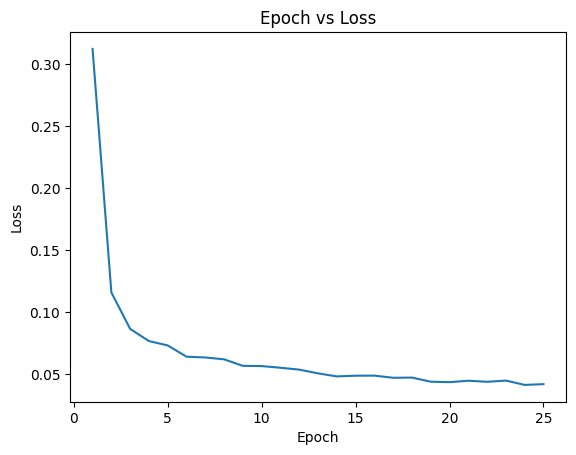

In [2]:
import matplotlib.pyplot as plt

epochs = [x['epoch'] for x in final_fold_results]
losses = [x['epoch_loss'] for x in final_fold_results]

plt.plot(epochs, losses)
plt.title('Epoch vs Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [3]:
metrics = ['accuracy', 'precision', 'recall', 'F1', 'AUC']

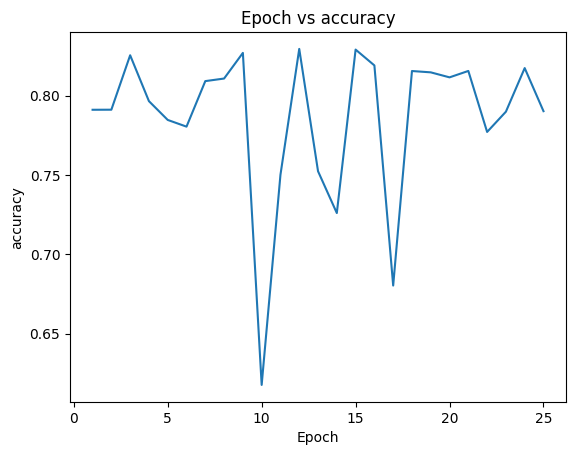

<Figure size 100x100 with 0 Axes>

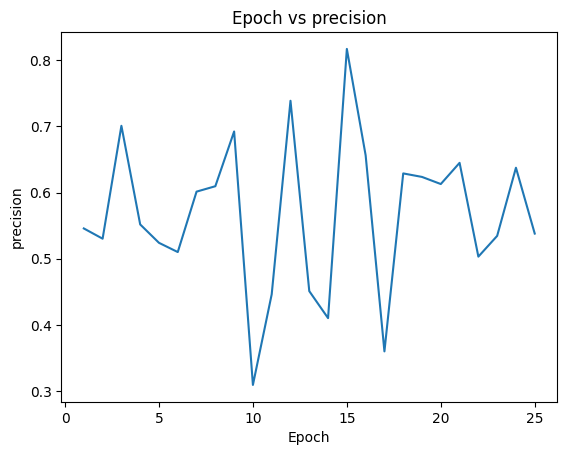

<Figure size 100x100 with 0 Axes>

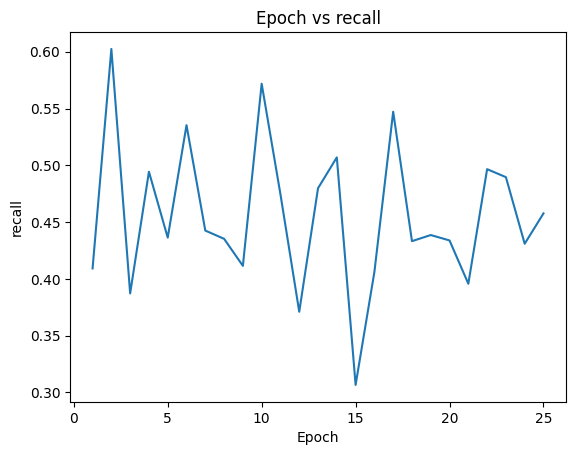

<Figure size 100x100 with 0 Axes>

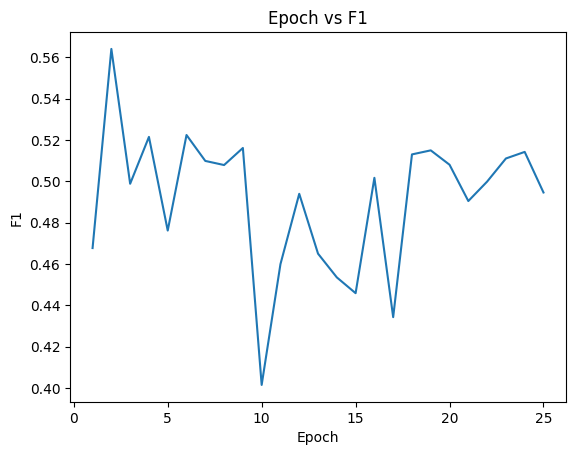

<Figure size 100x100 with 0 Axes>

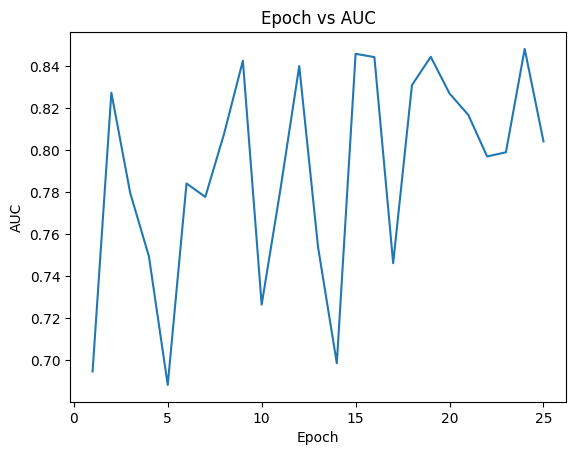

<Figure size 100x100 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt

for metric in metrics:

    epochs = [x['epoch'] for x in final_fold_results]
    losses = [x[metric] for x in final_fold_results]

    plt.plot(epochs, losses)
    plt.title(f'Epoch vs {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(f'{metric}')
    plt.figure(figsize=(1, 1))
    plt.show()

In [7]:
summary_results = {}

metric_keys = [k for k in fold_results[0].keys() if k != 'cm']

for key in metric_keys:
    values = [fold[key] for fold in fold_results]
    summary_results[key] = {
        'mean': np.mean(values),
        'std': np.std(values)
    }

summary_results

{'accuracy': {'mean': 0.7820411024277372, 'std': 0.0886581985340694},
 'precision': {'mean': 0.5692077854733111, 'std': 0.10903519280667204},
 'recall': {'mean': 0.6897855738194788, 'std': 0.21035913866383318},
 'f1': {'mean': 0.6176130522123198, 'std': 0.14716605771701244},
 'auc': {'mean': 0.8339888183813964, 'std': 0.11152611496436408}}